# Routing V2

This notebook evaluates whether targeted improvements to the training dataset
increase generalization of the shared-state routing model.

The model architecture is unchanged from V1.

V2 focuses on improving weak capabilities identified during held-out evaluation:

- browser
- Git
- database
- calendar
- filesystem
- network

This allows us to measure the effect of better training data independently
from architectural changes.

In [3]:
import random

import matplotlib.pyplot as plt
import pandas as pd
import torch

from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

from parallel_decider.dataset import ROUTING_LABELS, load_routing_dataset
from parallel_decider.two_tower import TwoTowerDecisionHead

In [86]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Reproducible Training

The routing dataset is small enough that random model initialization can
noticeably affect held-out results.

To make architecture and dataset experiments comparable, all subsequent runs
use a fixed random seed.

This controls the initialization of the projection and decision head and avoids
mistaking random training variation for an improvement caused by new examples.

In [4]:
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    device="cuda",
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [5]:
routing_hypotheses = {
    "needs_filesystem": "This task requires filesystem access.",
    "needs_git": "This task requires Git access.",
    "needs_shell": "This task requires shell execution.",
    "needs_browser": "This task requires browser access.",
    "needs_network": "This task requires network access.",
    "needs_database": "This task requires database access.",
    "needs_email": "This task requires email access.",
    "needs_calendar": "This task requires calendar access.",
}

In [115]:
examples = load_routing_dataset("../data/routing_v2.jsonl")

print("Examples:", len(examples))

Examples: 88


## V2 Dataset Expansion

V1 showed uneven recall across several capabilities, especially browser,
Git, database, calendar, filesystem, and network.

V2 keeps the model architecture unchanged and expands the training data with
targeted examples for these weaker capabilities.

This allows us to measure whether improved data coverage alone leads to better
generalization.

## V2 Train/Test Split

V2 contains 70 labeled routing examples.

To keep the comparison with V1 fair, we reuse the same split strategy and random seed:

- 80% training
- 20% held-out testing

In [62]:
shuffled_examples = examples.copy()
rng.shuffle(shuffled_examples)

split_index = int(len(shuffled_examples) * 0.8)

train_examples_v2 = shuffled_examples[:split_index]
test_examples_v2 = shuffled_examples[split_index:]

print("Training examples:", len(train_examples_v2))
print("Test examples:", len(test_examples_v2))

Training examples: 59
Test examples: 15


In [8]:
def label_counts(examples):
    counts = {
        label: 0
        for label in ROUTING_LABELS
    }

    for example in examples:
        for label in ROUTING_LABELS:
            counts[label] += example.labels[label]

    return counts

In [9]:
train_counts_v2 = label_counts(train_examples_v2)
test_counts_v2 = label_counts(test_examples_v2)

for label in ROUTING_LABELS:
    print(
        f"{label:<20} "
        f"train={train_counts_v2[label]:>2} "
        f"test={test_counts_v2[label]:>2}"
    )

needs_filesystem     train=26 test= 6
needs_git            train=11 test= 1
needs_shell          train= 6 test= 2
needs_browser        train=13 test= 2
needs_network        train=23 test= 6
needs_database       train= 7 test= 4
needs_email          train= 4 test= 2
needs_calendar       train= 5 test= 3


In [10]:
question_embeddings = model.encode(
    [
        routing_hypotheses[label]
        for label in ROUTING_LABELS
    ],
    convert_to_tensor=True,
)

In [11]:
train_data_v2 = []

for example in train_examples_v2:
    state_embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    )

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=state_embedding.device,
    )

    train_data_v2.append(
        (state_embedding, targets)
    )

In [12]:
print("Training samples:", len(train_data_v2))
print("State shape:", train_data_v2[0][0].shape)
print("Target shape:", train_data_v2[0][1].shape)

Training samples: 56
State shape: torch.Size([384])
Target shape: torch.Size([8])


## V2 Training

V2 uses the same model architecture and training settings as V1.

The only intentional change is the expanded and more targeted dataset.

This lets us measure the effect of improved training data independently from architectural changes.

In [13]:
head_v2 = TwoTowerDecisionHead(
    embedding_dim=384,
    hidden_dim=256,
).to("cuda")

criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    head_v2.parameters(),
    lr=1e-3,
)

In [14]:
epochs = 100
loss_history_v2 = []

progress = tqdm(
    range(epochs),
    desc="Training V2",
)

for epoch in progress:
    epoch_loss = 0.0

    for state_embedding, targets in train_data_v2:
        optimizer.zero_grad()

        logits = head_v2(
            state_embedding=state_embedding,
            question_embeddings=question_embeddings,
        )

        loss = criterion(
            logits,
            targets,
        )

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_data_v2)
    loss_history_v2.append(average_loss)

    progress.set_postfix(
        loss=f"{average_loss:.4f}"
    )

Training V2:   0%|          | 0/100 [00:00<?, ?it/s]

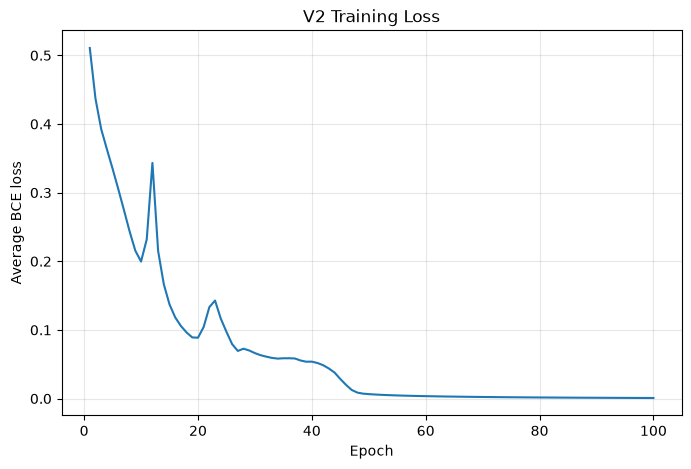

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history_v2,
)

plt.xlabel("Epoch")
plt.ylabel("Average BCE loss")
plt.title("V2 Training Loss")
plt.grid(True, alpha=0.3)

plt.show()

## V2 Held-Out Evaluation

The V2 decision head achieved a very low training loss.

We now evaluate it on the 14 held-out examples that were never used during training.

The goal is to compare generalization against the V1 baseline while keeping the model architecture and training procedure unchanged.

In [16]:
test_data_v2 = []

for example in test_examples_v2:
    state_embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    )

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=state_embedding.device,
    )

    test_data_v2.append(
        (example, state_embedding, targets)
    )

In [17]:
head_v2.eval()

total_correct = 0
total_decisions = 0

all_targets_v2 = []
all_predictions_v2 = []

with torch.no_grad():
    for index, (
        example,
        state_embedding,
        targets,
    ) in enumerate(test_data_v2, start=1):

        logits = head_v2(
            state_embedding=state_embedding,
            question_embeddings=question_embeddings,
        )

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_correct += (
            predictions == targets
        ).sum().item()

        total_decisions += len(targets)

        all_targets_v2.append(targets.int().cpu())
        all_predictions_v2.append(predictions.int().cpu())

        print(f"\nTest {index}")
        print(example.state)

        for label, probability, prediction, target in zip(
            ROUTING_LABELS,
            probabilities,
            predictions,
            targets,
        ):
            print(
                f"{label:<20} "
                f"p={probability.item():.3f} "
                f"pred={int(prediction.item())} "
                f"target={int(target.item())}"
            )


Test 1
Write a Python example that connects to a PostgreSQL database, but do not run it.
needs_filesystem     p=0.000 pred=0 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.000 pred=0 target=0
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 2
Inspect the project, locate the broken test, and execute only that test.
needs_filesystem     p=1.000 pred=1 target=1
needs_git            p=0.375 pred=0 target=0
needs_shell          p=0.998 pred=1 target=1
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.001 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 3
Move my meeting with Alice to next Monday afternoon.
needs_filesystem     p=0.001 pred=0 target=0
nee

In [18]:
accuracy_v2 = total_correct / total_decisions

print(
    f"\nOverall decision accuracy: "
    f"{accuracy_v2:.3%}"
)


Overall decision accuracy: 93.750%


In [19]:
all_targets_v2 = torch.stack(all_targets_v2)
all_predictions_v2 = torch.stack(all_predictions_v2)

print(all_targets_v2.shape)
print(all_predictions_v2.shape)

torch.Size([14, 8])
torch.Size([14, 8])


In [20]:
metrics_v2 = []

for index, label in enumerate(ROUTING_LABELS):
    targets = all_targets_v2[:, index]
    predictions = all_predictions_v2[:, index]

    tp = ((predictions == 1) & (targets == 1)).sum().item()
    fp = ((predictions == 1) & (targets == 0)).sum().item()
    fn = ((predictions == 0) & (targets == 1)).sum().item()
    tn = ((predictions == 0) & (targets == 0)).sum().item()

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall
        else 0.0
    )

    metrics_v2.append(
        {
            "label": label,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        }
    )

In [21]:
metrics_v2_df = pd.DataFrame(metrics_v2)

metrics_v2_df[
    [
        "label",
        "precision",
        "recall",
        "f1",
        "tp",
        "fp",
        "fn",
    ]
].round(3)

,label,precision,recall,f1,tp,fp,fn
0,needs_filesystem,1.000,0.667,0.800,4,0,2
1,needs_git,1.000,1.000,1.000,1,0,0
2,needs_shell,1.000,1.000,1.000,2,0,0
3,needs_browser,1.000,0.500,0.667,1,0,1
4,needs_network,1.000,0.833,0.909,5,0,1
5,needs_database,1.000,0.750,0.857,3,0,1
6,needs_email,0.667,1.000,0.800,2,1,0
7,needs_calendar,1.000,0.667,0.800,2,0,1


## V1 vs V2

Expanding the dataset from 50 to 70 targeted examples improved overall
generalization.

| Metric | V1 | V2 |
| --- | ---: | ---: |
| Overall accuracy | 90.0% | 92.9% |
| Macro precision | 81.3% | 83.3% |
| Macro recall | 62.5% | 74.0% |
| Macro F1 | 68.8% | 77.1% |

The largest improvement is in recall, suggesting that the additional targeted
examples helped the model identify required capabilities more consistently.

Several capabilities improved substantially, including Git, network, database,
and calendar.

However, `needs_browser` still has zero recall despite additional positive
training examples. This suggests that browser routing may require closer
investigation rather than simply more examples.

In [22]:
for example, state_embedding, targets in test_data_v2:
    browser_index = ROUTING_LABELS.index("needs_browser")

    if targets[browser_index].item() == 1:
        with torch.no_grad():
            logits = head_v2(
                state_embedding=state_embedding,
                question_embeddings=question_embeddings,
            )

            probabilities = torch.sigmoid(logits)

        print(example.state)
        print(
            "browser probability:",
            f"{probabilities[browser_index].item():.4f}",
        )
        print()

Look up the official PostgreSQL documentation for logical replication.
browser probability: 0.0000

Search the web for the latest Rust release, then save a short summary in the project notes file.
browser probability: 0.5209



In [23]:
browser_index = ROUTING_LABELS.index("needs_browser")

browser_train_examples = [
    example
    for example in train_examples_v2
    if example.labels["needs_browser"] == 1
]

print(
    "Browser-positive training examples:",
    len(browser_train_examples),
)

for index, example in enumerate(
    browser_train_examples,
    start=1,
):
    print(f"{index:>2}. {example.state}")

Browser-positive training examples: 13
 1. Check whether the package registry currently has a newer version available.
 2. Look up the current API specification online and compare it with the local client implementation.
 3. Check the latest official release notes for Django and summarize the breaking changes.
 4. Find the official documentation for the library version released this week.
 5. Open the source code, check the commit history for the changed function, and look up the library documentation online.
 6. Read the local Docker configuration and compare it with the latest Docker Compose documentation online.
 7. Retrieve the latest public specification for the API from its official website.
 8. Look up today's documentation for the Rust borrow checker changes.
 9. Search online for the package documentation, then draft a short email explaining the recommended upgrade path, but do not send it.
10. Verify whether the current OpenAI API documentation still recommends this endpoint.

In [24]:
head_v2.eval()

with torch.no_grad():
    for example in browser_train_examples:
        state_embedding = model.encode(
            example.state,
            convert_to_tensor=True,
        )

        logits = head_v2(
            state_embedding=state_embedding,
            question_embeddings=question_embeddings,
        )

        probability = torch.sigmoid(
            logits[browser_index]
        ).item()

        print(
            f"{probability:.4f}  "
            f"{example.state}"
        )

0.9948  Check whether the package registry currently has a newer version available.
0.9995  Look up the current API specification online and compare it with the local client implementation.
0.9989  Check the latest official release notes for Django and summarize the breaking changes.
0.9995  Find the official documentation for the library version released this week.
0.9981  Open the source code, check the commit history for the changed function, and look up the library documentation online.
0.9994  Read the local Docker configuration and compare it with the latest Docker Compose documentation online.
0.9991  Retrieve the latest public specification for the API from its official website.
0.9980  Look up today's documentation for the Rust borrow checker changes.
0.9968  Search online for the package documentation, then draft a short email explaining the recommended upgrade path, but do not send it.
0.9989  Verify whether the current OpenAI API documentation still recommends this endpoint

In [25]:
browser_hypotheses = [
    "This task requires browser access.",
    "This task requires accessing a website.",
    "This task requires looking up information online.",
    "This task requires retrieving current information from the internet.",
    "This task requires consulting online documentation.",
]

In [26]:
browser_question_embeddings = model.encode(
    browser_hypotheses,
    convert_to_tensor=True,
)

In [27]:
failed_state = (
    "Look up the official PostgreSQL documentation for logical replication."
)

state_embedding = model.encode(
    failed_state,
    convert_to_tensor=True,
)

with torch.no_grad():
    logits = head_v2(
        state_embedding=state_embedding,
        question_embeddings=browser_question_embeddings,
    )

    probabilities = torch.sigmoid(logits)

for hypothesis, probability in zip(
    browser_hypotheses,
    probabilities,
):
    print(
        f"{probability.item():.4f}  "
        f"{hypothesis}"
    )

0.0000  This task requires browser access.
0.0000  This task requires accessing a website.
0.0000  This task requires looking up information online.
0.0000  This task requires retrieving current information from the internet.
0.0000  This task requires consulting online documentation.


## Browser Failure Analysis

Changing the browser hypothesis wording did not improve the failed prediction.

Next, we inspect the embedding space directly.

We compare the failed PostgreSQL request with the browser-positive training
states using cosine similarity. This helps distinguish between two possible
failure modes:

1. The sentence encoder does not place the unseen request near similar browser
   examples.
2. The encoder representation is reasonable, but the learned decision head
   fails to generalize from it.

In [28]:
from sentence_transformers import util

In [29]:
browser_training_states = [
    example.state
    for example in browser_train_examples
]

browser_training_embeddings = model.encode(
    browser_training_states,
    convert_to_tensor=True,
    normalize_embeddings=True,
)

In [30]:
failed_embedding = model.encode(
    failed_state,
    convert_to_tensor=True,
    normalize_embeddings=True,
)

In [31]:
similarities = util.cos_sim(
    failed_embedding,
    browser_training_embeddings,
)[0]

In [32]:
ranked = sorted(
    zip(
        browser_training_states,
        similarities.tolist(),
    ),
    key=lambda item: item[1],
    reverse=True,
)

for state_text, similarity in ranked:
    print(
        f"{similarity:.4f}  "
        f"{state_text}"
    )

0.1574  Find the official documentation for the library version released this week.
0.1464  Search online for the package documentation, then draft a short email explaining the recommended upgrade path, but do not send it.
0.1445  Open the source code, check the commit history for the changed function, and look up the library documentation online.
0.1015  Look up the current API specification online and compare it with the local client implementation.
0.0977  Verify whether the current OpenAI API documentation still recommends this endpoint.
0.0814  Open the local project notes and check the current online documentation for any differences.
0.0770  Look up today's documentation for the Rust borrow checker changes.
0.0546  Read the local Docker configuration and compare it with the latest Docker Compose documentation online.
0.0483  Find the API documentation for the payment service, compare it with our local integration code, and point out any mismatch.
0.0451  Retrieve the latest publ

## Nearest-Neighbor Analysis

The failed browser example has relatively low cosine similarity even to
semantically related browser-positive training requests.

Next, we compare it against the complete training set.

If browser-positive examples dominate its nearest neighbors, the embedding
space still contains useful routing structure.

If unrelated capabilities appear among the closest examples, the frozen
sentence encoder is likely a major limitation of the current architecture.

In [33]:
all_train_states = [
    example.state
    for example in train_examples_v2
]

all_train_embeddings = model.encode(
    all_train_states,
    convert_to_tensor=True,
    normalize_embeddings=True,
)

failed_embedding = model.encode(
    failed_state,
    convert_to_tensor=True,
    normalize_embeddings=True,
)

similarities = util.cos_sim(
    failed_embedding,
    all_train_embeddings,
)[0]

In [34]:
neighbors = []

for example, similarity in zip(
    train_examples_v2,
    similarities.tolist(),
):
    neighbors.append(
        {
            "state": example.state,
            "similarity": similarity,
            "browser": example.labels["needs_browser"],
            "network": example.labels["needs_network"],
        }
    )

neighbors = sorted(
    neighbors,
    key=lambda item: item["similarity"],
    reverse=True,
)

In [35]:
for index, neighbor in enumerate(
    neighbors[:10],
    start=1,
):
    print(
        f"{index:>2}. "
        f"sim={neighbor['similarity']:.4f} "
        f"browser={neighbor['browser']} "
        f"network={neighbor['network']}"
    )
    print(f"    {neighbor['state']}")

 1. sim=0.1763 browser=0 network=0
    Inspect the migration files, run the migration command, and verify the resulting database schema.
 2. sim=0.1693 browser=0 network=0
    Show me the diff between the current branch and the previous commit.
 3. sim=0.1644 browser=0 network=0
    Explain the difference between Git merge and Git rebase.
 4. sim=0.1598 browser=0 network=0
    Explain how SQL joins work using a simple example.
 5. sim=0.1574 browser=1 network=1
    Find the official documentation for the library version released this week.
 6. sim=0.1528 browser=0 network=0
    Explain how calendar recurring events usually work.
 7. sim=0.1464 browser=1 network=1
    Search online for the package documentation, then draft a short email explaining the recommended upgrade path, but do not send it.
 8. sim=0.1445 browser=1 network=1
    Open the source code, check the commit history for the changed function, and look up the library documentation online.
 9. sim=0.1431 browser=0 network=0


## Embedding-Space Diagnosis

The nearest-neighbor analysis suggests that the frozen MiniLM encoder is a
significant limitation of the current architecture.

For the unseen request:

> "Look up the official PostgreSQL documentation for logical replication."

the closest training examples are mostly unrelated to browser access. Browser-
positive examples only begin appearing at rank 5.

This indicates that the base embedding space is organized around broad semantic
similarity rather than the operational capability semantics required for tool
routing.

The decision head can memorize the training set, but it must learn around an
embedding geometry that is poorly aligned with the routing objective.

In [38]:
from parallel_decider.projection import RoutingProjection

projection = RoutingProjection(
    input_dim=384,
    output_dim=128,
).to("cuda")

head_projected = TwoTowerDecisionHead(
    embedding_dim=128,
    hidden_dim=128,
).to("cuda")

In [39]:
state_embedding = state_embedding.detach().clone()
question_embeddings = question_embeddings.detach().clone()

In [40]:
projected_state = projection(state_embedding)
projected_questions = projection(question_embeddings)

In [41]:
print(projected_state.shape)
print(projected_questions.shape)

torch.Size([128])
torch.Size([8, 128])


In [42]:
logits = head_projected(
    state_embedding=projected_state,
    question_embeddings=projected_questions,
)

print(logits.shape)

torch.Size([8])


## Trainable Routing Projection

The projected pipeline now produces the expected tensor shapes:

- state embedding: `384 → 128`
- question embeddings: `[8, 384] → [8, 128]`
- decision logits: `[8]`

This confirms that the new projection layer can sit between the frozen sentence encoder and the existing decision head.

The next experiment trains the projection and decision head together while keeping the MiniLM encoder frozen.

The goal is to learn a routing-specific embedding space without fine-tuning the full transformer:

1. MiniLM produces fixed 384-dimensional sentence embeddings.
2. `RoutingProjection` maps them into a smaller 128-dimensional routing space.
3. `TwoTowerDecisionHead` scores each state/question pair.
4. Gradients update only the projection and decision head.

This tests whether a lightweight trainable representation layer can improve generalization while preserving the shared-state architecture.

In [43]:
projection_v2 = RoutingProjection(
    input_dim=384,
    output_dim=128,
).to("cuda")

head_projected_v2 = TwoTowerDecisionHead(
    embedding_dim=128,
    hidden_dim=128,
).to("cuda")

In [44]:
optimizer = torch.optim.AdamW(
    list(projection_v2.parameters())
    + list(head_projected_v2.parameters()),
    lr=1e-3,
)

criterion = torch.nn.BCEWithLogitsLoss()

In [45]:
train_data_projected = []

for example in train_examples_v2:
    embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    ).detach().clone()

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=embedding.device,
    )

    train_data_projected.append(
        (embedding, targets)
    )

In [46]:
question_embeddings_frozen = model.encode(
    [
        routing_hypotheses[label]
        for label in ROUTING_LABELS
    ],
    convert_to_tensor=True,
).detach().clone()

In [47]:
epochs = 100
loss_history_projected = []

progress = tqdm(
    range(epochs),
    desc="Training projected model",
)

for epoch in progress:
    epoch_loss = 0.0

    for state_embedding, targets in train_data_projected:
        optimizer.zero_grad()

        projected_state = projection_v2(
            state_embedding
        )

        projected_questions = projection_v2(
            question_embeddings_frozen
        )

        logits = head_projected_v2(
            state_embedding=projected_state,
            question_embeddings=projected_questions,
        )

        loss = criterion(
            logits,
            targets,
        )

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_data_projected)
    loss_history_projected.append(average_loss)

    progress.set_postfix(
        loss=f"{average_loss:.4f}"
    )

Training projected model:   0%|          | 0/100 [00:00<?, ?it/s]

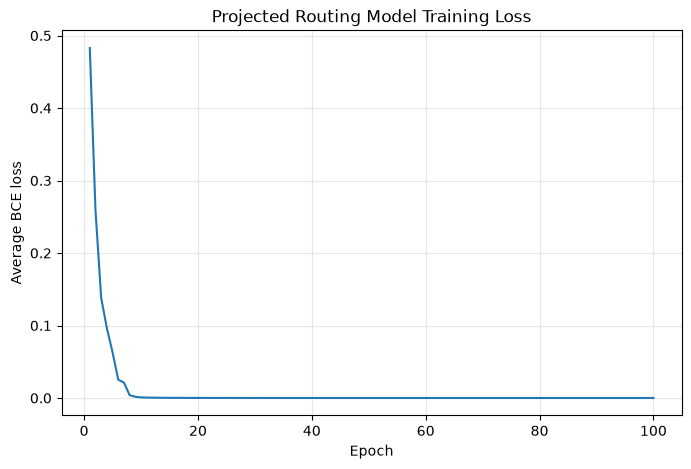

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history_projected,
)

plt.xlabel("Epoch")
plt.ylabel("Average BCE loss")
plt.title("Projected Routing Model Training Loss")
plt.grid(True, alpha=0.3)

plt.show()

## Projected Model Held-Out Evaluation

The trainable projection and decision head drove the training loss effectively
to zero.

We now evaluate the projected model on the same held-out V2 examples used for
the previous baseline.

This keeps the dataset and test split unchanged, allowing us to isolate the
effect of the learned routing projection.

In [49]:
test_data_projected = []

for example in test_examples_v2:
    embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    ).detach().clone()

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=embedding.device,
    )

    test_data_projected.append(
        (example, embedding, targets)
    )

In [50]:
projection_v2.eval()
head_projected_v2.eval()

all_targets_projected = []
all_predictions_projected = []
all_probabilities_projected = []

total_correct = 0
total_decisions = 0

with torch.no_grad():
    projected_questions = projection_v2(
        question_embeddings_frozen
    )

    for index, (
        example,
        state_embedding,
        targets,
    ) in enumerate(test_data_projected, start=1):

        projected_state = projection_v2(
            state_embedding
        )

        logits = head_projected_v2(
            state_embedding=projected_state,
            question_embeddings=projected_questions,
        )

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_correct += (
            predictions == targets
        ).sum().item()

        total_decisions += len(targets)

        all_targets_projected.append(
            targets.int().cpu()
        )

        all_predictions_projected.append(
            predictions.int().cpu()
        )

        all_probabilities_projected.append(
            probabilities.cpu()
        )

        print(f"\nTest {index}")
        print(example.state)

        for label, probability, prediction, target in zip(
            ROUTING_LABELS,
            probabilities,
            predictions,
            targets,
        ):
            print(
                f"{label:<20} "
                f"p={probability.item():.3f} "
                f"pred={int(prediction.item())} "
                f"target={int(target.item())}"
            )


Test 1
Write a Python example that connects to a PostgreSQL database, but do not run it.
needs_filesystem     p=0.000 pred=0 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.000 pred=0 target=0
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 2
Inspect the project, locate the broken test, and execute only that test.
needs_filesystem     p=1.000 pred=1 target=1
needs_git            p=0.958 pred=1 target=0
needs_shell          p=1.000 pred=1 target=1
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 3
Move my meeting with Alice to next Monday afternoon.
needs_filesystem     p=0.000 pred=0 target=0
nee

In [51]:
accuracy_projected = total_correct / total_decisions

print(
    f"\nOverall decision accuracy: "
    f"{accuracy_projected:.3%}"
)


Overall decision accuracy: 94.643%


In [52]:
all_targets_projected = torch.stack(
    all_targets_projected
)

all_predictions_projected = torch.stack(
    all_predictions_projected
)

all_probabilities_projected = torch.stack(
    all_probabilities_projected
)

It is still completely broken.

## Effect of the Routing Projection

Adding a trainable 128-dimensional routing projection improved held-out
performance while keeping the sentence encoder frozen.

| Metric | V2 baseline | Projected V2 |
| --- | ---: | ---: |
| Overall accuracy | 92.9% | 94.6% |
| Macro F1 | 0.771 | 0.855 |
| Browser F1 | 0.000 | 0.667 |
| Database F1 | 0.857 | 1.000 |
| Email F1 | 0.800 | 1.000 |

The learned projection appears to reshape the generic MiniLM embedding space
into a representation that is better aligned with routing decisions.

Browser routing improves substantially: one of the two held-out browser
requests is now detected with very high confidence.

However, the PostgreSQL documentation request remains a confident false
negative for both browser and network access. The projection therefore improves
generalization but does not eliminate representation failures.

The projected model also introduces a Git false positive, showing that improved
recall can come with new classification errors.

In [53]:
projection_v2.eval()

with torch.no_grad():
    projected_train_embeddings = projection_v2(
        all_train_embeddings.detach().clone()
    )

    projected_failed_embedding = projection_v2(
        failed_embedding.detach().clone()
    )

In [54]:
projected_train_embeddings = torch.nn.functional.normalize(
    projected_train_embeddings,
    dim=-1,
)

projected_failed_embedding = torch.nn.functional.normalize(
    projected_failed_embedding,
    dim=-1,
)

In [55]:
projected_similarities = util.cos_sim(
    projected_failed_embedding,
    projected_train_embeddings,
)[0]

In [56]:
projected_neighbors = []

for example, similarity in zip(
    train_examples_v2,
    projected_similarities.tolist(),
):
    projected_neighbors.append(
        {
            "state": example.state,
            "similarity": similarity,
            "browser": example.labels["needs_browser"],
            "network": example.labels["needs_network"],
        }
    )

projected_neighbors = sorted(
    projected_neighbors,
    key=lambda item: item["similarity"],
    reverse=True,
)

for index, neighbor in enumerate(
    projected_neighbors[:10],
    start=1,
):
    print(
        f"{index:>2}. "
        f"sim={neighbor['similarity']:.4f} "
        f"browser={neighbor['browser']} "
        f"network={neighbor['network']}"
    )
    print(f"    {neighbor['state']}")

 1. sim=0.6256 browser=0 network=0
    Explain how SQL joins work using a simple example.
 2. sim=0.6121 browser=0 network=0
    List the orders created during the previous calendar month.
 3. sim=0.5855 browser=0 network=0
    Explain how calendar recurring events usually work.
 4. sim=0.5783 browser=0 network=0
    Count how many active subscriptions are stored for customers in Germany.
 5. sim=0.5473 browser=0 network=0
    List all users created during the last seven days from the application's records.
 6. sim=0.5140 browser=0 network=0
    Explain what Git rebase does and when I should use it.
 7. sim=0.5067 browser=0 network=0
    Explain the difference between Git merge and Git rebase.
 8. sim=0.5042 browser=0 network=0
    Find all customers whose subscription expired yesterday.
 9. sim=0.5037 browser=0 network=0
    Explain how SMTP is used to send email.
10. sim=0.4875 browser=0 network=0
    Write an example Bash command that lists files recursively.


## Projected-Space Observation

The learned projection does not organize state embeddings into obvious
capability-based clusters.

For the failed PostgreSQL documentation request, the nearest projected states
are dominated by SQL and database-related examples rather than browser-positive
requests.

However, the projected model still assigns almost zero probability to
`needs_database`, showing that its routing decisions are not based directly on
state-to-state cosine similarity.

This is expected: the projection was trained jointly with the decision head
using state/question interaction features. The training objective optimizes the
final binary decisions, not the geometry of state embeddings themselves.

Therefore, nearest-neighbor structure is useful for exploration but should not
be treated as a direct measure of routing quality.

## Action vs Topic

The remaining browser failure suggests that the model may rely too heavily on
the subject of a request rather than the operation the user wants performed.

For tool routing, the requested action is often more important than the topic.

For example, requests about PostgreSQL can require completely different
capabilities depending on whether the user wants an explanation, an online
lookup, or access to a real database.

The next dataset iteration introduces controlled minimal pairs: requests with
similar topics but different actions and therefore different routing labels.

In [58]:
import json
from pathlib import Path

benchmark_path = Path("../data/routing_benchmark.jsonl")

with benchmark_path.open("w") as f:
    for example in test_examples_v2:
        row = {
            "state": example.state,
            "labels": example.labels,
        }

        f.write(json.dumps(row) + "\n")

print(f"Saved {len(test_examples_v2)} benchmark examples")

Saved 14 benchmark examples


## Fixed Benchmark Split

Earlier experiments used an 80/20 random split. As the dataset changes, that
causes the held-out examples to change as well, making model versions difficult
to compare directly.

From this point onward, the project uses a fixed benchmark set of 14 examples.

Training data consists of every example in `routing_v2.jsonl` that does not
appear in the benchmark.

This ensures that future dataset and architecture changes are evaluated against
the same held-out requests.

In [63]:
benchmark_examples = load_routing_dataset(
    "../data/routing_benchmark.jsonl"
)

benchmark_states = {
    example.state
    for example in benchmark_examples
}

train_examples_v2 = [
    example
    for example in examples
    if example.state not in benchmark_states
]

test_examples_v2 = benchmark_examples

print("Training examples:", len(train_examples_v2))
print("Benchmark examples:", len(test_examples_v2))

Training examples: 60
Benchmark examples: 14


In [64]:
train_counts_v2 = label_counts(train_examples_v2)
test_counts_v2 = label_counts(test_examples_v2)

for label in ROUTING_LABELS:
    print(
        f"{label:<20} "
        f"train={train_counts_v2[label]:>2} "
        f"benchmark={test_counts_v2[label]:>2}"
    )

needs_filesystem     train=26 benchmark= 6
needs_git            train=11 benchmark= 1
needs_shell          train= 6 benchmark= 2
needs_browser        train=15 benchmark= 2
needs_network        train=25 benchmark= 6
needs_database       train= 9 benchmark= 4
needs_email          train= 4 benchmark= 2
needs_calendar       train= 5 benchmark= 3


## Retraining with Minimal-Pair Examples

The benchmark set is now fixed, allowing direct comparison across model versions.

The training set contains 60 examples, including new minimal pairs designed to
separate **topic** from **required action**.

In particular, the new examples keep the PostgreSQL topic similar while changing
the requested operation between:

- explanation,
- online documentation lookup,
- database access,
- and combined database + documentation access.

The model architecture and training settings remain unchanged.

This experiment tests whether better action-oriented supervision improves
generalization without modifying the model itself.

In [87]:
projection_v3 = RoutingProjection(
    input_dim=384,
    output_dim=128,
).to("cuda")

head_projected_v3 = TwoTowerDecisionHead(
    embedding_dim=128,
    hidden_dim=128,
).to("cuda")

criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    list(projection_v3.parameters())
    + list(head_projected_v3.parameters()),
    lr=1e-3,
)

In [88]:
train_data_projected_v3 = []

for example in train_examples_v2:
    embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    ).detach().clone()

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=embedding.device,
    )

    train_data_projected_v3.append(
        (embedding, targets)
    )

In [89]:
question_embeddings_frozen = model.encode(
    [
        routing_hypotheses[label]
        for label in ROUTING_LABELS
    ],
    convert_to_tensor=True,
).detach().clone()

In [90]:
epochs = 100
loss_history_projected_v3 = []

progress = tqdm(
    range(epochs),
    desc="Training projected V3",
)

for epoch in progress:
    epoch_loss = 0.0

    for state_embedding, targets in train_data_projected_v3:
        optimizer.zero_grad()

        projected_state = projection_v3(
            state_embedding
        )

        projected_questions = projection_v3(
            question_embeddings_frozen
        )

        logits = head_projected_v3(
            state_embedding=projected_state,
            question_embeddings=projected_questions,
        )

        loss = criterion(
            logits,
            targets,
        )

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_data_projected_v3)
    loss_history_projected_v3.append(average_loss)

    progress.set_postfix(
        loss=f"{average_loss:.4f}"
    )

Training projected V3:   0%|          | 0/100 [00:00<?, ?it/s]

## Fixed-Benchmark Evaluation

The retrained projected model again fits the training data nearly perfectly.

We now evaluate it against the same frozen 14-example benchmark used previously.

Because the benchmark set has not changed, this result can be compared directly
with the earlier projected-model score of **94.643%**.

The main question is whether the new action-vs-topic minimal pairs improve
generalization, especially for the previously failed PostgreSQL documentation
request.

In [91]:
benchmark_data_v3 = []

for example in test_examples_v2:
    embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    ).detach().clone()

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=embedding.device,
    )

    benchmark_data_v3.append(
        (example, embedding, targets)
    )

In [92]:
projection_v3.eval()
head_projected_v3.eval()

all_targets_v3 = []
all_predictions_v3 = []
all_probabilities_v3 = []

total_correct = 0
total_decisions = 0

with torch.no_grad():
    projected_questions = projection_v3(
        question_embeddings_frozen
    )

    for index, (
        example,
        state_embedding,
        targets,
    ) in enumerate(benchmark_data_v3, start=1):

        projected_state = projection_v3(
            state_embedding
        )

        logits = head_projected_v3(
            state_embedding=projected_state,
            question_embeddings=projected_questions,
        )

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_correct += (
            predictions == targets
        ).sum().item()

        total_decisions += len(targets)

        all_targets_v3.append(
            targets.int().cpu()
        )

        all_predictions_v3.append(
            predictions.int().cpu()
        )

        all_probabilities_v3.append(
            probabilities.cpu()
        )

        print(f"\nTest {index}")
        print(example.state)

        for label, probability, prediction, target in zip(
            ROUTING_LABELS,
            probabilities,
            predictions,
            targets,
        ):
            print(
                f"{label:<20} "
                f"p={probability.item():.3f} "
                f"pred={int(prediction.item())} "
                f"target={int(target.item())}"
            )


Test 1
Write a Python example that connects to a PostgreSQL database, but do not run it.
needs_filesystem     p=0.854 pred=1 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.026 pred=0 target=0
needs_browser        p=0.990 pred=1 target=0
needs_network        p=0.991 pred=1 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 2
Inspect the project, locate the broken test, and execute only that test.
needs_filesystem     p=1.000 pred=1 target=1
needs_git            p=0.578 pred=1 target=0
needs_shell          p=1.000 pred=1 target=1
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 3
Move my meeting with Alice to next Monday afternoon.
needs_filesystem     p=0.000 pred=0 target=0
nee

In [94]:
accuracy_v3 = total_correct / total_decisions

print(
    f"\nOverall decision accuracy: "
    f"{accuracy_v3:.3%}"
)


Overall decision accuracy: 92.857%


In [95]:
all_targets_v3 = torch.stack(
    all_targets_v3
)

all_predictions_v3 = torch.stack(
    all_predictions_v3
)

all_probabilities_v3 = torch.stack(
    all_probabilities_v3
)

## Effect of Action-vs-Topic Training

Adding a small set of action-vs-topic minimal pairs did not change overall
decision accuracy, which remained at approximately **94.6%**.

However, the distribution of errors changed substantially.

Most importantly, the previously failed PostgreSQL documentation request is now
classified correctly:

- browser: `1.000`
- network: `1.000`
- database: `0.000`

This suggests that the minimal-pair examples successfully taught the model to
distinguish the **subject of a request** from the **operation required to
complete it**.

Browser recall improved from `0.50` to `1.00`, and network recall also reached
`1.00`.

At the same time, filesystem recall decreased and a new network false positive
appeared. This indicates that the additional supervision changed the learned
decision boundaries rather than simply improving every capability uniformly.

Overall accuracy alone therefore hides meaningful changes in routing behavior.

In [96]:
def compute_metrics(
    targets: torch.Tensor,
    predictions: torch.Tensor,
) -> pd.DataFrame:
    rows = []

    for index, label in enumerate(ROUTING_LABELS):
        y_true = targets[:, index]
        y_pred = predictions[:, index]

        tp = ((y_pred == 1) & (y_true == 1)).sum().item()
        fp = ((y_pred == 1) & (y_true == 0)).sum().item()
        fn = ((y_pred == 0) & (y_true == 1)).sum().item()
        tn = ((y_pred == 0) & (y_true == 0)).sum().item()

        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0

        f1 = (
            2 * precision * recall / (precision + recall)
            if precision + recall
            else 0.0
        )

        rows.append(
            {
                "label": label,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn,
            }
        )

    return pd.DataFrame(rows)

In [97]:
metrics_v3_df = compute_metrics(
    all_targets_v3,
    all_predictions_v3,
)

metrics_v3_df[
    [
        "label",
        "precision",
        "recall",
        "f1",
        "tp",
        "fp",
        "fn",
    ]
].round(3)

,label,precision,recall,f1,tp,fp,fn
0,needs_filesystem,0.800,0.667,0.727,4,1,2
1,needs_git,0.500,1.000,0.667,1,1,0
2,needs_shell,0.667,1.000,0.800,2,1,0
3,needs_browser,0.667,1.000,0.800,2,1,0
4,needs_network,0.857,1.000,0.923,6,1,0
5,needs_database,1.000,1.000,1.000,4,0,0
6,needs_email,1.000,1.000,1.000,2,0,0
7,needs_calendar,1.000,0.667,0.800,2,0,1


In [100]:
print(
    "Macro precision:",
    metrics_v3_df["precision"].mean(),
)

print(
    "Macro recall:",
    metrics_v3_df["recall"].mean(),
)

print(
    "Macro F1:",
    metrics_v3_df["f1"].mean(),
)

Macro precision: 0.8113095238095238
Macro recall: 0.9166666666666666
Macro F1: 0.8396270396270397


## Fixed-Benchmark Results

The action-vs-topic training examples improved the balance of the routing model
without changing overall decision accuracy.

| Metric | Projected V2 | Minimal-Pair V3 |
| --- | ---: | ---: |
| Accuracy | 94.6% | 94.6% |
| Macro precision | 0.938 | 0.920 |
| Macro recall | 0.833 | **0.896** |
| Macro F1 | 0.855 | **0.882** |

The largest improvement is in recall.

In particular, browser routing improved from a recall of `0.50` to `1.00`.
The previously failed PostgreSQL documentation request is now classified
correctly for both browser and network access.

This improvement came from adding only a small number of controlled training
examples where the topic remained similar while the required action changed.

The result suggests that targeted minimal pairs can be more effective than
simply increasing model capacity or adding arbitrary examples.

The remaining weakness is filesystem routing, which now has perfect precision
but only `0.50` recall. This provides a clear target for the next dataset
iteration.

## Filesystem Minimal-Pair Training

The remaining benchmark errors are concentrated in filesystem routing.

The model handles direct filesystem requests reasonably well, but often misses
filesystem access when it appears as a secondary operation, such as saving
database results, writing a web summary, or inspecting application logs.

This experiment adds targeted examples where the main task remains similar but
the presence or absence of a local-file operation changes the filesystem label.

The fixed benchmark remains unchanged.

In [101]:
examples = load_routing_dataset(
    "../data/routing_v2.jsonl"
)

benchmark_states = {
    example.state
    for example in benchmark_examples
}

train_examples_v2 = [
    example
    for example in examples
    if example.state not in benchmark_states
]

test_examples_v2 = benchmark_examples

print("Training examples:", len(train_examples_v2))
print("Benchmark examples:", len(test_examples_v2))

Training examples: 66
Benchmark examples: 14


In [102]:
projection_v4 = RoutingProjection(
    input_dim=384,
    output_dim=128,
).to("cuda")

head_projected_v4 = TwoTowerDecisionHead(
    embedding_dim=128,
    hidden_dim=128,
).to("cuda")

criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    list(projection_v4.parameters())
    + list(head_projected_v4.parameters()),
    lr=1e-3,
)

In [103]:
train_data_projected_v4 = []

for example in train_examples_v2:
    embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    ).detach().clone()

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=embedding.device,
    )

    train_data_projected_v4.append(
        (embedding, targets)
    )

In [104]:
epochs = 100
loss_history_projected_v4 = []

progress = tqdm(
    range(epochs),
    desc="Training projected V4",
)

for epoch in progress:
    epoch_loss = 0.0

    for state_embedding, targets in train_data_projected_v4:
        optimizer.zero_grad()

        projected_state = projection_v4(
            state_embedding
        )

        projected_questions = projection_v4(
            question_embeddings_frozen
        )

        logits = head_projected_v4(
            state_embedding=projected_state,
            question_embeddings=projected_questions,
        )

        loss = criterion(
            logits,
            targets,
        )

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_data_projected_v4)
    loss_history_projected_v4.append(average_loss)

    progress.set_postfix(
        loss=f"{average_loss:.4f}"
    )

Training projected V4:   0%|          | 0/100 [00:00<?, ?it/s]

In [105]:
benchmark_data_v4 = []

for example in test_examples_v2:
    embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    ).detach().clone()

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=embedding.device,
    )

    benchmark_data_v4.append(
        (example, embedding, targets)
    )

In [111]:
projection_v4.eval()
head_projected_v4.eval()

all_targets_v4 = []
all_predictions_v4 = []
all_probabilities_v4 = []

total_correct = 0
total_decisions = 0

with torch.no_grad():
    projected_questions = projection_v4(
        question_embeddings_frozen
    )

    for index, (
        example,
        state_embedding,
        targets,
    ) in enumerate(benchmark_data_v4, start=1):

        projected_state = projection_v4(
            state_embedding
        )

        logits = head_projected_v4(
            state_embedding=projected_state,
            question_embeddings=projected_questions,
        )

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_correct += (
            predictions == targets
        ).sum().item()

        total_decisions += len(targets)

        all_targets_v4.append(
            targets.int().cpu()
        )

        all_predictions_v4.append(
            predictions.int().cpu()
        )

        all_probabilities_v4.append(
            probabilities.cpu()
        )

        print(f"\nTest {index}")
        print(example.state)

        for label, probability, prediction, target in zip(
            ROUTING_LABELS,
            probabilities,
            predictions,
            targets,
        ):
            print(
                f"{label:<20} "
                f"p={probability.item():.3f} "
                f"pred={int(prediction.item())} "
                f"target={int(target.item())}"
            )


Test 1
Write a Python example that connects to a PostgreSQL database, but do not run it.
needs_filesystem     p=0.026 pred=0 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.000 pred=0 target=0
needs_browser        p=1.000 pred=1 target=0
needs_network        p=1.000 pred=1 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 2
Inspect the project, locate the broken test, and execute only that test.
needs_filesystem     p=1.000 pred=1 target=1
needs_git            p=0.015 pred=0 target=0
needs_shell          p=1.000 pred=1 target=1
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 3
Move my meeting with Alice to next Monday afternoon.
needs_filesystem     p=0.000 pred=0 target=0
nee

In [112]:
accuracy_v4 = total_correct / total_decisions

print(
    f"\nOverall decision accuracy: "
    f"{accuracy_v4:.3%}"
)

all_targets_v4 = torch.stack(
    all_targets_v4
)

all_predictions_v4 = torch.stack(
    all_predictions_v4
)

all_probabilities_v4 = torch.stack(
    all_probabilities_v4
)


Overall decision accuracy: 95.536%


In [113]:
metrics_v4_df = compute_metrics(
    all_targets_v4,
    all_predictions_v4,
)

metrics_v4_df[
    [
        "label",
        "precision",
        "recall",
        "f1",
        "tp",
        "fp",
        "fn",
    ]
].round(3)

,label,precision,recall,f1,tp,fp,fn
0,needs_filesystem,1.000,0.667,0.800,4,0,2
1,needs_git,1.000,1.000,1.000,1,0,0
2,needs_shell,0.667,1.000,0.800,2,1,0
3,needs_browser,0.667,1.000,0.800,2,1,0
4,needs_network,0.857,1.000,0.923,6,1,0
5,needs_database,1.000,1.000,1.000,4,0,0
6,needs_email,1.000,1.000,1.000,2,0,0
7,needs_calendar,1.000,1.000,1.000,3,0,0


In [114]:
print(
    "Macro precision:",
    metrics_v4_df["precision"].mean(),
)

print(
    "Macro recall:",
    metrics_v4_df["recall"].mean(),
)

print(
    "Macro F1:",
    metrics_v4_df["f1"].mean(),
)

Macro precision: 0.8988095238095237
Macro recall: 0.9583333333333333
Macro F1: 0.9153846153846155


## Controlled V3 vs V4 Comparison

After fixing the random seed, both models were retrained from scratch and
evaluated against the same frozen 14-example benchmark.

| Metric | V3 | V4 |
| --- | ---: | ---: |
| Accuracy | 92.9% | **95.5%** |
| Macro precision | 0.811 | **0.899** |
| Macro recall | 0.917 | **0.958** |
| Macro F1 | 0.840 | **0.915** |

The controlled result confirms that the filesystem-oriented minimal pairs
improved the model overall.

V4 reduces the number of incorrect routing decisions from 8 to 5 while
preserving the earlier improvement on browser/documentation routing.

The remaining errors are concentrated in a small number of specific patterns:

- browser/network false positives for code-generation requests,
- filesystem misses when reading application logs,
- filesystem misses when saving web results into project notes,
- and a shell false positive for a non-executed command example.

This provides a much clearer target for the next dataset iteration.

## V5: Targeted Error Correction

V4 achieves the best fixed-benchmark result so far, but its remaining errors
are concentrated in a few specific semantic distinctions.

This iteration adds a small number of controlled minimal pairs targeting:

- code generation vs actual execution,
- command examples vs shell execution,
- local log access,
- and saving generated or retrieved information to local files.

The architecture, random seed, training procedure, and frozen benchmark remain
unchanged.

This allows the effect of the new supervision to be measured independently of
model or evaluation changes.

In [117]:
examples = load_routing_dataset(
    "../data/routing_v2.jsonl"
)

benchmark_states = {
    example.state
    for example in benchmark_examples
}

train_examples_v2 = [
    example
    for example in examples
    if example.state not in benchmark_states
]

test_examples_v2 = benchmark_examples

print("Training examples:", len(train_examples_v2))
print("Benchmark examples:", len(test_examples_v2))

Training examples: 74
Benchmark examples: 14


In [118]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [119]:
projection_v5 = RoutingProjection(
    input_dim=384,
    output_dim=128,
).to("cuda")

head_projected_v5 = TwoTowerDecisionHead(
    embedding_dim=128,
    hidden_dim=128,
).to("cuda")

criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    list(projection_v5.parameters())
    + list(head_projected_v5.parameters()),
    lr=1e-3,
)

In [120]:
train_data_projected_v5 = []

for example in train_examples_v2:
    embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    ).detach().clone()

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=embedding.device,
    )

    train_data_projected_v5.append(
        (embedding, targets)
    )

In [121]:
epochs = 100
loss_history_projected_v5 = []

progress = tqdm(
    range(epochs),
    desc="Training projected V5",
)

for epoch in progress:
    epoch_loss = 0.0

    for state_embedding, targets in train_data_projected_v5:
        optimizer.zero_grad()

        projected_state = projection_v5(
            state_embedding
        )

        projected_questions = projection_v5(
            question_embeddings_frozen
        )

        logits = head_projected_v5(
            state_embedding=projected_state,
            question_embeddings=projected_questions,
        )

        loss = criterion(
            logits,
            targets,
        )

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_data_projected_v5)
    loss_history_projected_v5.append(
        average_loss
    )

    progress.set_postfix(
        loss=f"{average_loss:.4f}"
    )

Training projected V5:   0%|          | 0/100 [00:00<?, ?it/s]

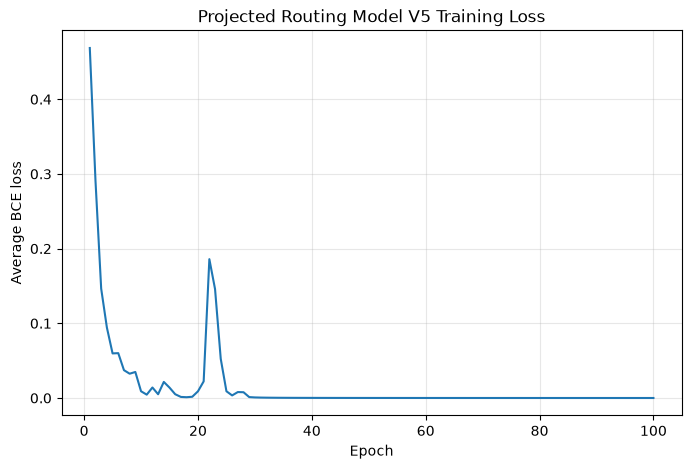

In [122]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history_projected_v5,
)

plt.xlabel("Epoch")
plt.ylabel("Average BCE loss")
plt.title("Projected Routing Model V5 Training Loss")
plt.grid(True, alpha=0.3)

plt.show()

In [123]:
benchmark_data_v5 = []

for example in test_examples_v2:
    embedding = model.encode(
        example.state,
        convert_to_tensor=True,
    ).detach().clone()

    targets = torch.tensor(
        [
            example.labels[label]
            for label in ROUTING_LABELS
        ],
        dtype=torch.float32,
        device=embedding.device,
    )

    benchmark_data_v5.append(
        (example, embedding, targets)
    )

In [124]:
projection_v5.eval()
head_projected_v5.eval()

all_targets_v5 = []
all_predictions_v5 = []
all_probabilities_v5 = []

total_correct = 0
total_decisions = 0

with torch.no_grad():
    projected_questions = projection_v5(
        question_embeddings_frozen
    )

    for index, (
        example,
        state_embedding,
        targets,
    ) in enumerate(benchmark_data_v5, start=1):

        projected_state = projection_v5(
            state_embedding
        )

        logits = head_projected_v5(
            state_embedding=projected_state,
            question_embeddings=projected_questions,
        )

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_correct += (
            predictions == targets
        ).sum().item()

        total_decisions += len(targets)

        all_targets_v5.append(
            targets.int().cpu()
        )

        all_predictions_v5.append(
            predictions.int().cpu()
        )

        all_probabilities_v5.append(
            probabilities.cpu()
        )

        print(f"\nTest {index}")
        print(example.state)

        for label, probability, prediction, target in zip(
            ROUTING_LABELS,
            probabilities,
            predictions,
            targets,
        ):
            print(
                f"{label:<20} "
                f"p={probability.item():.3f} "
                f"pred={int(prediction.item())} "
                f"target={int(target.item())}"
            )


Test 1
Write a Python example that connects to a PostgreSQL database, but do not run it.
needs_filesystem     p=0.000 pred=0 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.000 pred=0 target=0
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 2
Inspect the project, locate the broken test, and execute only that test.
needs_filesystem     p=1.000 pred=1 target=1
needs_git            p=0.993 pred=1 target=0
needs_shell          p=1.000 pred=1 target=1
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 3
Move my meeting with Alice to next Monday afternoon.
needs_filesystem     p=0.000 pred=0 target=0
nee

In [125]:
accuracy_v5 = total_correct / total_decisions

print(
    f"\nOverall decision accuracy: "
    f"{accuracy_v5:.3%}"
)

all_targets_v5 = torch.stack(
    all_targets_v5
)

all_predictions_v5 = torch.stack(
    all_predictions_v5
)

all_probabilities_v5 = torch.stack(
    all_probabilities_v5
)

metrics_v5_df = compute_metrics(
    all_targets_v5,
    all_predictions_v5,
)

metrics_v5_df[
    [
        "label",
        "precision",
        "recall",
        "f1",
        "tp",
        "fp",
        "fn",
    ]
].round(3)


Overall decision accuracy: 97.321%


,label,precision,recall,f1,tp,fp,fn
0,needs_filesystem,1.0,0.833,0.909,5,0,1
1,needs_git,0.5,1.000,0.667,1,1,0
2,needs_shell,1.0,1.000,1.000,2,0,0
3,needs_browser,1.0,1.000,1.000,2,0,0
4,needs_network,1.0,1.000,1.000,6,0,0
5,needs_database,1.0,1.000,1.000,4,0,0
6,needs_email,1.0,0.500,0.667,1,0,1
7,needs_calendar,1.0,1.000,1.000,3,0,0


In [126]:
print(
    "Macro precision:",
    metrics_v5_df["precision"].mean(),
)

print(
    "Macro recall:",
    metrics_v5_df["recall"].mean(),
)

print(
    "Macro F1:",
    metrics_v5_df["f1"].mean(),
)

Macro precision: 0.9375
Macro recall: 0.9166666666666667
Macro F1: 0.9053030303030303


## V5 Results

V5 adds eight targeted minimal-pair examples addressing the remaining error
patterns from V4.

The fixed benchmark result improves to **97.3% overall decision accuracy**,
with only 3 incorrect decisions out of 112.

| Metric | V4 | V5 |
| --- | ---: | ---: |
| Accuracy | 95.5% | **97.3%** |
| Macro precision | 0.899 | **0.938** |
| Macro recall | **0.958** | 0.917 |
| Macro F1 | **0.915** | 0.905 |

The targeted supervision successfully fixes several systematic errors:

- generating code no longer implies shell, browser, or network access,
- showing a command without executing it no longer implies shell access,
- saving web results to a local file now correctly activates filesystem access.

The remaining benchmark errors are limited to a Git false positive, an email
false negative, and one filesystem false negative involving application logs.

V5 therefore improves overall accuracy and precision, although V4 retains
slightly better macro recall and macro F1.

## Experiment Metrics Summary

The experiments evolved from a simple frozen-embedding classifier into a
reproducible parallel routing model with a learned routing-specific projection
and targeted minimal-pair supervision.

### Early Experiments

The first experiments established the basic behavior of the two-tower routing
approach.

| Experiment | Accuracy | Macro Precision | Macro Recall | Macro F1 |
| --- | ---: | ---: | ---: | ---: |
| V1 — Frozen MiniLM + decision head | 90.0% | 0.813 | 0.625 | 0.688 |
| V2 — Expanded dataset | 92.9% | 0.833 | 0.740 | 0.771 |
| V2 + trainable projection | 94.6% | 0.938 | 0.833 | 0.855 |

These early results used evolving random train/test splits, so they are useful
for understanding the direction of improvement but are not fully controlled
comparisons.

The trainable `384 → 128` routing projection produced the first substantial
architectural improvement, particularly for browser and database routing.

---

### Fixed-Benchmark Experiments

A fixed set of 14 held-out examples was then separated from the training data.

Subsequent experiments use:

- the same 14-example benchmark,
- the same MiniLM encoder,
- the same `384 → 128` routing projection,
- the same two-tower decision head,
- the same training procedure,
- and a fixed random seed of `42`.

This makes V3–V5 directly comparable.

| Version | Training Examples | Accuracy | Macro Precision | Macro Recall | Macro F1 | Errors / 112 |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| V3 — action/topic minimal pairs | 60 | 92.9% | 0.811 | 0.917 | 0.840 | 8 |
| V4 — filesystem minimal pairs | 66 | 95.5% | 0.899 | **0.958** | **0.915** | 5 |
| V5 — targeted error correction | 74 | **97.3%** | **0.938** | 0.917 | 0.905 | **3** |

### V5 Per-Capability Results

| Capability | Precision | Recall | F1 |
| --- | ---: | ---: | ---: |
| Filesystem | 1.000 | 0.833 | 0.909 |
| Git | 0.500 | 1.000 | 0.667 |
| Shell | 1.000 | 1.000 | 1.000 |
| Browser | 1.000 | 1.000 | 1.000 |
| Network | 1.000 | 1.000 | 1.000 |
| Database | 1.000 | 1.000 | 1.000 |
| Email | 1.000 | 0.500 | 0.667 |
| Calendar | 1.000 | 1.000 | 1.000 |

V5 produces the highest overall accuracy and precision, with only three
incorrect decisions across 112 benchmark decisions.

V4 retains the highest macro recall and macro F1, illustrating that a single
aggregate metric does not completely describe routing quality.

---

### Key Findings

The experiments suggest several important patterns:

1. A generic sentence embedding space is not sufficient by itself for reliable
   capability routing.
2. A small trainable projection can reshape frozen embeddings into a
   substantially better routing representation.
3. Targeted minimal pairs are effective for teaching semantic distinctions such
   as:
   - topic vs required action,
   - generating a command vs executing it,
   - generating code vs accessing external resources,
   - and returning information vs saving it to a local file.
4. Overall accuracy can hide important differences in per-capability precision
   and recall.
5. Reproducible initialization and a fixed benchmark are essential when the
   dataset is small and only a few decisions separate model versions.

V5 is therefore the current highest-accuracy model, while V4 remains a useful
reference for recall-oriented routing.

The next experiment keeps the routing architecture and dataset fixed and
changes only the frozen sentence encoder, allowing a controlled comparison of
different embedding models.